# 긴급 EDA: `age=40` 미인증 폭증 현상 검증

이 노트북은 히스토그램에서 보였던 `age=40` 급증 현상을 **데이터로 재현하고**, 그 값이 정말 "실제 40대 증가"로 읽혀도 되는지 검증하기 위해 만들었다.

## 이 노트북의 핵심 질문
- `age=40` 폭증은 정말 미인증 고객 때문에 생긴 현상인가?
- `age=40`을 실제 40대로 해석해도 되는가?
- 이것이 단순 결측(`NaN`) 처리 문제인지, 특정 가입 경로의 demographic fallback인지, 혹은 실제 40대 증가인지 구분할 수 있는가?
- 문제의 집단은 가입 속성과 시청 콘텐츠 측면에서 어떤 특징을 가지는가?

## 분석 원칙
- demographic 해석은 **행(row)** 이 아니라 **고유 사용자(`user_no`)** 기준으로 먼저 확인한다.
- `Membership_Description.xlsx`의 정의를 먼저 확인하고, 그 뒤에 해석한다.
- 마지막에는 **확실한 사실**, **강한 가설**, **아직 단정하면 안 되는 것**을 분리해 정리한다.


**Project Root**: `C:\Code\OTT_Churn_Modeling_AX`

## 1. 데이터 정의 확인

,Name,Description,Example
9,is_user_verified,본인인증여부 (미인증시 성별/연령 부정확),Y
11,age,"연령대,5년단위 (31~35세:35)",20


**해석 포인트**
- `age`는 실제 나이가 아니라 **5년 단위 연령대 값**이다.
- `is_user_verified` 설명에 **미인증시 성별/연령 부정확**이라고 명시되어 있다.
- 따라서 히스토그램의 `40`은 먼저 `실제 40대`가 아니라 `age bucket 40`으로 읽는 것이 안전하다.

## 2. 원본 행 기준 vs 고유 사용자 기준 비교

...

basis,raw_rows,unique_users
metric,,
N_age40,3621,3493
N_total,4096,3954
Y_age40,1399,1372
Y_total,13487,13306


**해석 포인트**
- 중복 행이 약간 존재하지만, `age=40` 쏠림 현상은 **원본 행 기준이든 고유 사용자 기준이든 동일한 방향**으로 나타난다.
- 이후 demographic 해석은 사람 단위가 더 적절하므로 **고유 사용자 기준**으로 진행한다.

## 3. 인증 상태와 age 전체 분포

,is_user_verified,users
0,Y,13306
1,N,3954
2,NaN,585


verify_label,N,NaN,Y
age,,,
-999.0000,0,152,0
0.0000,0,5,0
5.0000,0,1,0
15.0000,7,20,297
20.0000,56,83,2313
25.0000,104,73,2850
30.0000,107,46,2525
35.0000,70,40,1646
40.0000,3493,84,1372


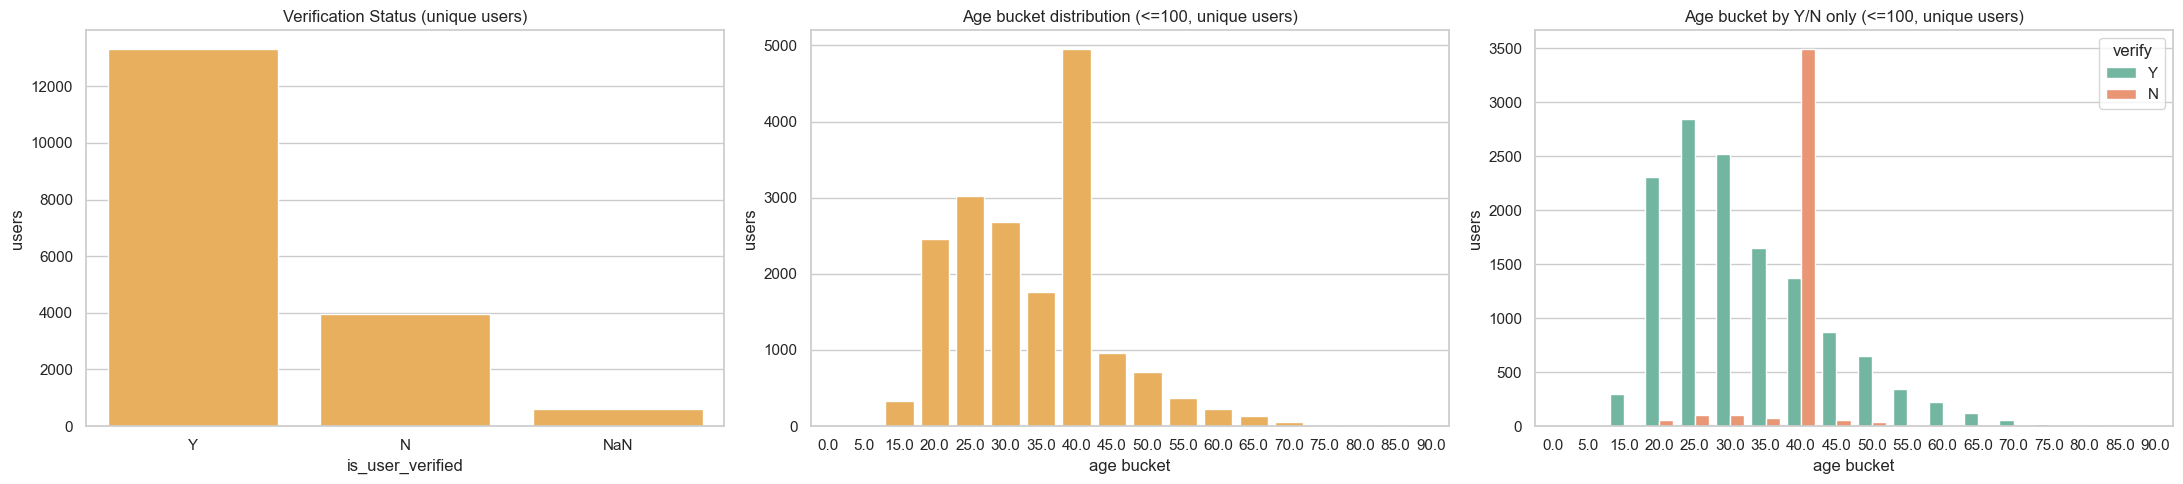

**1차 관찰 포인트**
- `age=40` 구간이 전체적으로 매우 크다.
- 그리고 그 증가분의 상당 부분이 `Y`보다 `N`에서 발생하는지 다음 섹션에서 정량 확인한다.

## 4. `age=40` 쏠림이 실제로 미인증이 만든 현상인지 정량 확인

### 4-1. 절대 수

is_user_verified,N,Y
age40_label,,
age!=40,461,11934
age=40,3493,1372


### 4-2. 행 비율: `age=40` 집단 안에서 Y/N 비중

is_user_verified,N,Y
age40_label,,
age!=40,3.7200,96.2800
age=40,71.8000,28.2000


### 4-3. 열 비율: 각 verify 그룹 안에서 `age=40` 비중

is_user_verified,N,Y
age40_label,,
age!=40,11.6600,89.6900
age=40,88.3400,10.3100


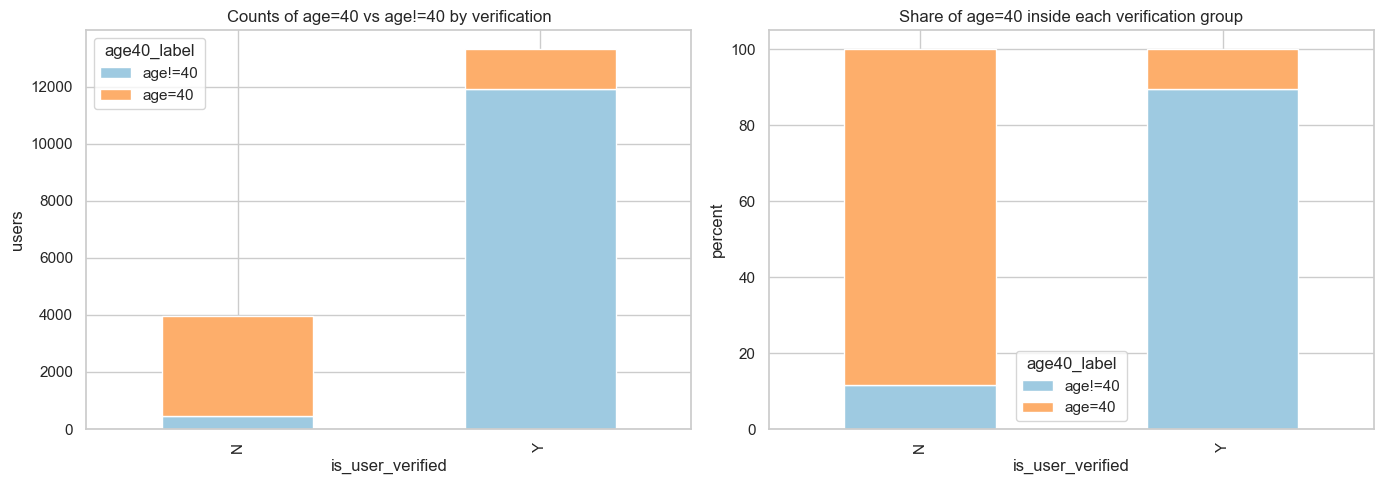

**핵심 수치 요약**
- 미인증 `N` 고유 사용자: **3,954명**
- 그중 `age=40`: **3,493명 (88.34%)**
- 인증 `Y` 고유 사용자: **13,306명**
- 그중 `age=40`: **1,372명 (10.31%)**
- 즉 `age=40` 폭증은 거의 대부분 **미인증 쪽에서 만들어진 현상**으로 볼 수 있다.

## 5. NaN / 이상치 점검: `NaN`이 40으로 바뀐 것인가?

,verify_label,age_missing_users
0,N,0
1,NaN,152
2,Y,0


### 5-1. `is_user_verified = NaN` 집단의 age 분포

,age,users
0,NaN,152
1,40.0000,84
2,20.0000,83
3,25.0000,73
4,30.0000,46
5,35.0000,40
6,45.0000,28
7,50.0000,23
8,15.0000,20
9,55.0000,14


...

,N_age40_share,N_non40_share
repurchase,,
O,68.3900,76.1400
NaN,31.6100,23.8600


### 6-is_churn_prevented. `is_churn_prevented` 분포 비교

,N_age40_share,N_non40_share
is_churn_prevented,,
NaN,92.5300,75.0500
O,7.4700,24.9500


### 6-concurrent_streams. `concurrent_streams` 분포 비교

,N_age40_share,N_non40_share
concurrent_streams,,
1.0000,69.5700,54.2300
2.0000,20.1500,26.6800
4.0000,9.2800,19.0900
NaN,0.9200,0.0000
3.0000,0.0900,0.0000


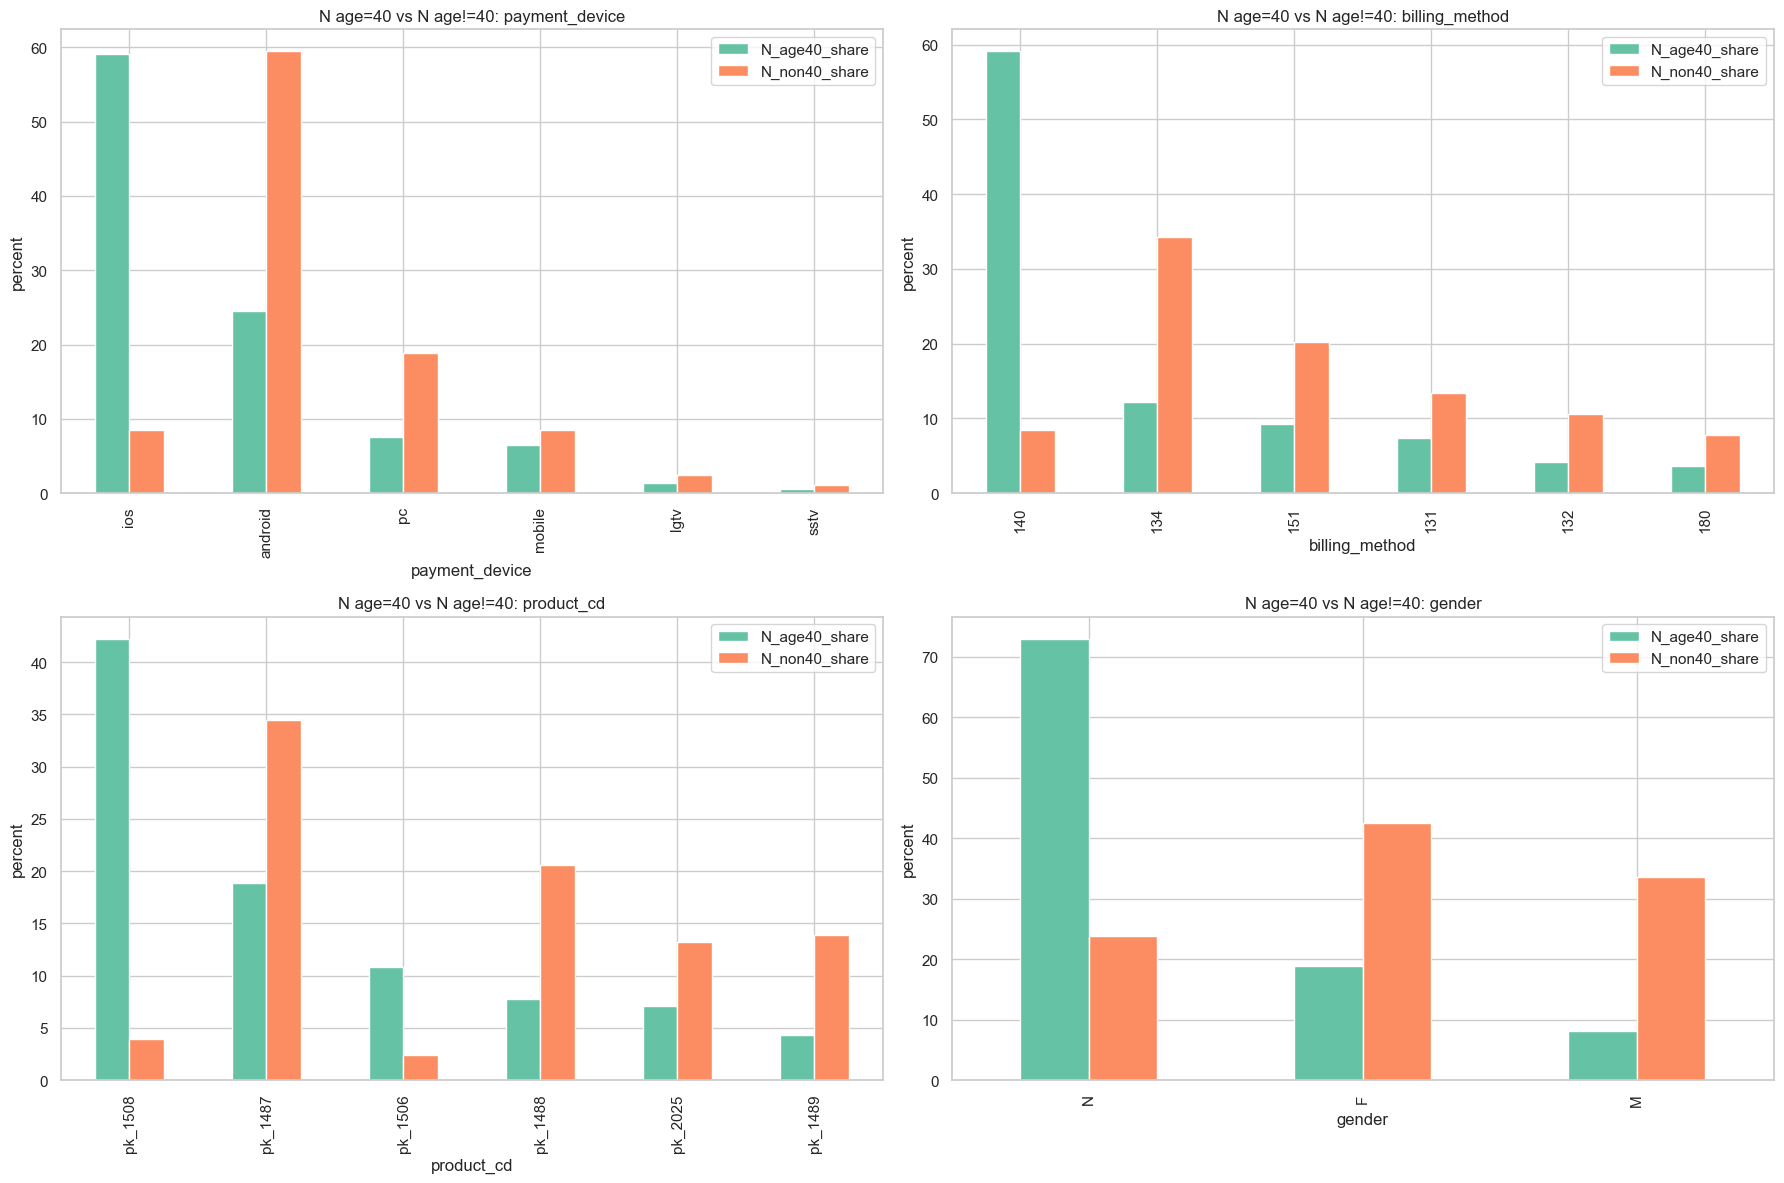

**관찰 포인트**
- `N age=40` 집단은 `N non40`보다 `ios`, `billing_method=140`, `product_cd=pk_1508`, `gender=N` 쏠림이 훨씬 강하다.
- 따라서 이 현상은 단순히 '미인증 전체의 일반적 나이 분포'라기보다, **특정 demographic 처리 + 특정 가입 경로 특성**이 겹친 결과로 보인다.

## 7. 특정 가입 경로 / 속성 조합 점검

### 7-1. `payment_device` x `billing_method` 교차표

billing_method,121,131,132,134,140,151,160,170,180,190
payment_device,,,,,,,,,,
android,1,1050,762,1971,0,3420,0,67,673,440
ios,0,0,0,0,2967,0,0,0,0,0
lgchplus,0,1,0,0,0,0,0,0,0,0
lgtv,0,31,13,69,0,0,0,2,11,12
mobile,0,312,468,816,0,0,0,90,538,509
ott,0,11,6,22,0,0,0,1,8,7
ott_cjhello,0,0,1,0,0,0,0,0,0,0
pc,0,428,566,1578,0,0,1,45,425,423
smarttv,1,3,1,2,0,0,0,0,0,0


### 7-2. 의심 코호트 크기

...

,billing_method,total,n,y,n40,share_n_in_group,share_n40_in_n,share_n40_in_total
4,140,2967,2103,788,2064,0.7088,0.9815,0.6957
3,134,4499,584,3754,426,0.1298,0.7295,0.0947
5,151,3420,417,2912,324,0.1219,0.7770,0.0947
1,131,1858,320,1475,258,0.1722,0.8063,0.1389
2,132,1831,194,1559,145,0.1060,0.7474,0.0792
8,180,1663,165,1439,129,0.0992,0.7818,0.0776
9,190,1397,134,1217,116,0.0959,0.8657,0.0830
7,170,207,36,161,30,0.1739,0.8333,0.1449


#### product_cd 기준

,product_cd,total,n,y,n40,share_n_in_group,share_n40_in_n,share_n40_in_total
30,pk_1508,2079,1494,530,1476,0.7186,0.9880,0.7100
24,pk_1487,6610,817,5614,658,0.1236,0.8054,0.0995
28,pk_1506,581,389,179,378,0.6695,0.9717,0.6506
25,pk_1488,2467,366,2035,271,0.1484,0.7404,0.1099
38,pk_2025,2222,309,1862,248,0.1391,0.8026,0.1116
26,pk_1489,2179,216,1794,152,0.0991,0.7037,0.0698
29,pk_1507,199,157,36,148,0.7889,0.9427,0.7437
39,pk_2026,616,67,539,50,0.1088,0.7463,0.0812
40,pk_2027,543,39,474,24,0.0718,0.6154,0.0442
36,pk_2005,113,13,97,10,0.1150,0.7692,0.0885


#### payment_device + billing_method + product_cd 기준

,payment_device,billing_method,product_cd,total,n,y,n40,share_n_in_group,share_n40_in_n,share_n40_in_total
56,ios,140,pk_1508,2079,1494,530,1476,0.7186,0.9880,0.7100
54,ios,140,pk_1506,581,389,179,378,0.6695,0.9717,0.6506
24,android,151,pk_2025,2222,309,1862,248,0.1391,0.8026,0.1116
20,android,134,pk_1487,1269,199,1056,150,0.1568,0.7538,0.1182
55,ios,140,pk_1507,199,157,36,148,0.7889,0.9427,0.7437
3,android,131,pk_1487,779,149,609,128,0.1913,0.8591,0.1643
134,pc,134,pk_1487,784,80,672,59,0.1020,0.7375,0.0753
34,android,180,pk_1487,479,61,406,52,0.1273,0.8525,0.1086
25,android,151,pk_2026,616,67,539,50,0.1088,0.7463,0.0812
11,android,132,pk_1487,442,58,371,41,0.1312,0.7069,0.0928


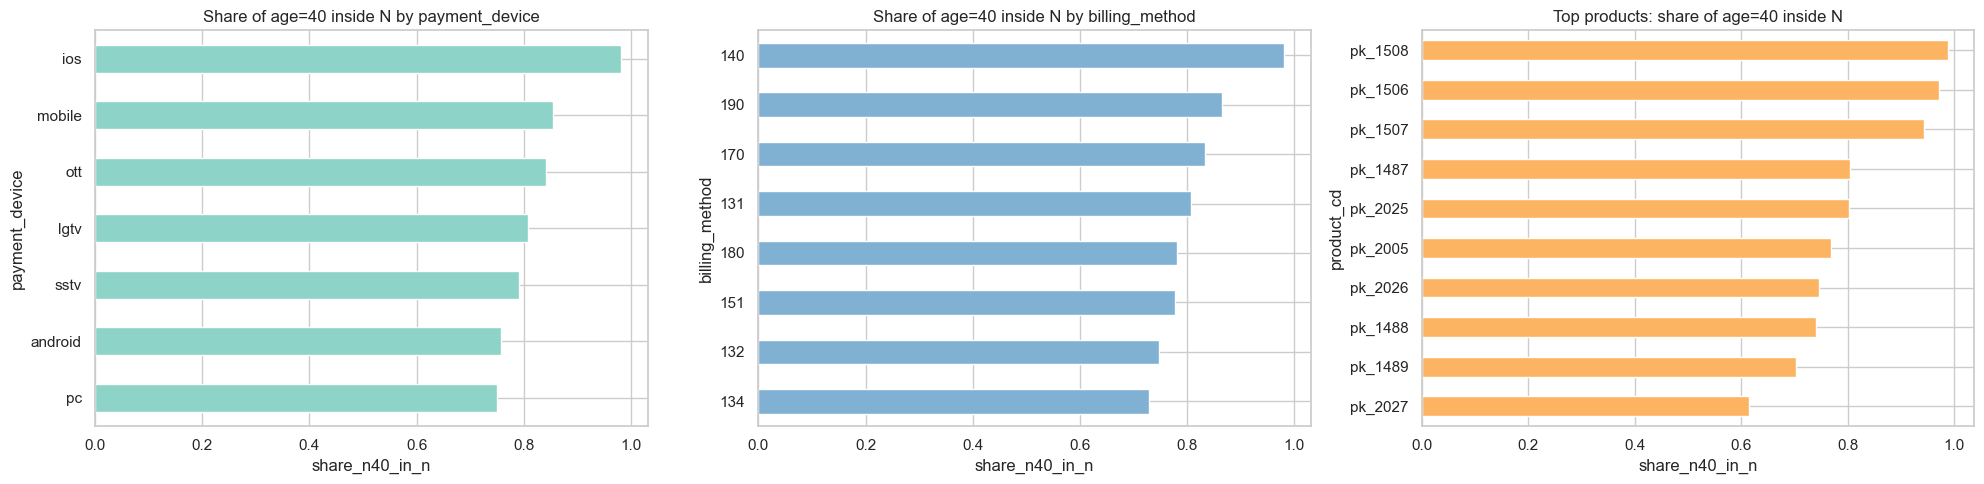

### 7-4. `gender` x `age` 교차표 (Y/N 분리)

#### N 그룹

age,15.0000,20.0000,25.0000,30.0000,35.0000,40.0000,45.0000,50.0000,55.0000,60.0000,65.0000,70.0000,80.0000,120.0000,950.0000
gender,,,,,,,,,,,,,,,
F,3,23,51,41,36,658,25,10,3,1,2,0,1,0,0
M,2,12,24,48,26,285,16,16,3,4,2,2,0,0,0
N,2,21,29,18,8,2550,14,11,4,1,0,0,0,1,1


#### Y 그룹

age,15.0000,20.0000,25.0000,30.0000,35.0000,40.0000,45.0000,50.0000,55.0000,60.0000,65.0000,70.0000,75.0000,80.0000,85.0000,90.0000
gender,,,,,,,,,,,,,,,,
F,193,1503,1866,1548,942,803,528,405,202,139,68,35,13,11,4,3
M,104,809,981,972,703,535,345,244,145,80,49,17,5,3,5,1
N,0,1,3,5,1,34,1,0,0,0,0,0,0,0,0,0


...

### 9-2. `Y age=40`에서 상대적으로 더 강한 작품

,MOVIE_ID,TITLE,n40_viewers,n40_share,y40_viewers,y40_share,rate_diff_n40_minus_y40
389,1900,죽여주는여자(2016),206.0000,0.0590,100.0000,0.0729,-0.0139
305,1494,디파이언스(2008),105.0000,0.0301,59.0000,0.0430,-0.0129
1710,8599,파커,110.0000,0.0315,58.0000,0.0423,-0.0108
1032,5184,궁(2013),207.0000,0.0593,96.0000,0.0700,-0.0107
732,3674,박화영,109.0000,0.0312,56.0000,0.0408,-0.0096
951,4792,더테이블,88.0000,0.0252,46.0000,0.0335,-0.0083
789,4008,바람의검심,4.0000,0.0011,13.0000,0.0095,-0.0083
1061,5298,해바라기,22.0000,0.0063,20.0000,0.0146,-0.0083
2121,10682,나이스가이즈,73.0000,0.0209,40.0000,0.0292,-0.0083
719,3620,천사의사랑,68.0000,0.0195,38.0000,0.0277,-0.0082


**콘텐츠 해석 포인트**
- `N age=40` 집단의 상위 작품은 전체 플랫폼 인기작과 거의 겹친다.
- 즉 이 집단이 완전히 별개의 취향 클러스터라기보다, **큰 미인증 demographic 버킷이 플랫폼 메인 콘텐츠를 소비하는 모습**에 더 가깝다.

## 10. 최종 정리

### 10-1. 이 노트북에서 확인된 사실
- `Membership_Description.xlsx` 기준으로 `age`는 실제 나이가 아니라 **5년 단위 age bucket**이다.
- 설명 파일에 **미인증시 성별/연령 부정확**이라고 명시되어 있다.
- 미인증 `N` 고유 사용자 **3,954명** 중 `age=40`은 **3,493명 (88.34%)** 이다.
- 인증 `Y` 고유 사용자 **13,306명** 중 `age=40`은 **1,372명 (10.31%)** 이다.
- `age` 결측은 존재하지만, 그것은 **`is_user_verified = NaN` 그룹에만 존재**한다.
- `N age=40` 집단은 `ios`, `billing_method=140`, `product_cd=pk_1508`, `gender=N` 쏠림이 강하다.
- `N age=40` 집단이 보는 콘텐츠 상위권은 전체 인기작과 **19/20개** 겹친다.

### 10-2. 강한 가설 (데이터가 매우 강하게 시사하지만, 코드/DB 로직 확인 전까지 100% 단정은 금지)
- `N` 그룹의 demographic 값은 실제 self-reported age라기보다 **fallback / placeholder / imputed value**처럼 저장된 흔적이 강하다.
- 특히 `age=40`은 '실제 40대가 많다'기보다 **미인증 demographic bucket이 몰린 값**일 가능성이 높다.
- 특정 가입 경로(`ios` / `billing=140` / 일부 상품)에서 이 현상이 특히 크게 보인다.

### 10-3. 아직 단정하면 안 되는 것
- **'시스템 default 값이 반드시 40이다'** 라고 단정하면 안 된다. 이 데이터만으로는 코드/ETL/DB 로직까지 볼 수 없기 때문이다.
- **'진짜 40대가 많이 유입되었다'** 라고 해석하면 위험하다.

### 10-4. 보고/발표용으로 가장 안전한 문장
> Membership의 age는 실제 나이가 아니라 5년 구간값이며, 설명 파일에도 미인증 사용자의 성별/연령은 부정확할 수 있다고 명시되어 있다. 실제로 미인증 사용자의 88.34%가 age=40에 집중되어 있어 이를 실제 40대로 해석하기 어렵다. 따라서 이 집단은 '실제 40대'보다는 '미인증 demographic bucket'으로 별도 해석하는 것이 타당하다.

> 또한 `N & age=40` 집단의 시청 콘텐츠는 플랫폼 전체 인기작과 대부분 겹치므로, 이 집단은 별개의 취향군이라기보다 큰 미인증 버킷이 주요 콘텐츠를 소비한 결과로 보는 편이 더 설득력 있다.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid", palette="Set2")


def locate_root() -> Path:
    candidates = [Path.cwd(), Path.cwd().parent]
    for candidate in candidates:
        if (candidate / "Dataset" / "Membership.xlsx").exists():
            return candidate.resolve()
    raise FileNotFoundError("Dataset/Membership.xlsx 를 기준으로 프로젝트 루트를 찾지 못했습니다.")


ROOT = locate_root()
DATA = ROOT / "Dataset"

membership = pd.read_excel(DATA / "Membership.xlsx")
desc = pd.read_excel(DATA / "Membership_Description.xlsx")
user_map = pd.read_excel(DATA / "User_Mapping.xlsx")
view_history = pd.read_excel(DATA / "View_History.xlsx")
movie_master = pd.read_excel(DATA / "Movie_Master.xlsx")

membership["age"] = pd.to_numeric(membership["age"], errors="coerce")
movie_master = movie_master[["MOVIE_ID", "TITLE"]].copy()
movie_master["TITLE"] = movie_master["TITLE"].astype(str)

# demographic 해석은 사용자 단위가 더 적절하므로 고유 user_no 기준 테이블을 따로 만든다.
membership_u = membership.drop_duplicates(subset=["user_no"]).copy()
user_map_u = user_map.drop_duplicates(subset=["uid"], keep="first").copy()


def pct(x: float) -> str:
    return f"{x * 100:.2f}%"


def compare_share(df_a: pd.DataFrame, df_b: pd.DataFrame, col: str, top_n: int = 10) -> pd.DataFrame:
    a = df_a[col].fillna("NaN").value_counts(normalize=True).rename("N_age40_share")
    b = df_b[col].fillna("NaN").value_counts(normalize=True).rename("N_non40_share")
    comp = pd.concat([a, b], axis=1).fillna(0)
    comp = comp.sort_values(["N_age40_share", "N_non40_share"], ascending=False).head(top_n)
    return (comp * 100).round(2)


def cohort_history(mask: pd.Series, label: str, top_n: int = 20):
    members = membership_u.loc[mask, ["user_no"]].drop_duplicates().copy()
    mapped = members.merge(user_map_u[["uid", "USER_ID"]], left_on="user_no", right_on="uid", how="inner")
    hist = mapped.merge(view_history[["USER_ID", "MOVIE_ID", "DURATION", "WATCH_DAY", "WATCH_SEQ"]], on="USER_ID", how="inner")
    hist = hist.merge(movie_master, on="MOVIE_ID", how="left")

    top = (
        hist.groupby(["MOVIE_ID", "TITLE"], sort=False)["USER_ID"]
        .nunique()
        .reset_index(name="unique_viewers")
        .sort_values(["unique_viewers", "MOVIE_ID"], ascending=[False, True])
        .head(top_n)
    )

    summary = pd.DataFrame(
        {
            "cohort": [label],
            "members": [members["user_no"].nunique()],
            "mapped_users": [mapped["USER_ID"].nunique()],
            "viewers_in_history": [hist["USER_ID"].nunique()],
            "view_rows": [len(hist)],
            "unique_titles": [hist["MOVIE_ID"].nunique()],
        }
    )
    return summary, top, hist


def title_rate_table(mask: pd.Series, label: str) -> pd.DataFrame:
    members = membership_u.loc[mask, ["user_no"]].drop_duplicates().copy()
    mapped = members.merge(user_map_u[["uid", "USER_ID"]], left_on="user_no", right_on="uid", how="inner")
    hist = mapped.merge(view_history[["USER_ID", "MOVIE_ID"]], on="USER_ID", how="inner")
    hist = hist.merge(movie_master, on="MOVIE_ID", how="left")

    out = (
        hist.groupby(["MOVIE_ID", "TITLE"], sort=False)["USER_ID"]
        .nunique()
        .reset_index(name=f"{label}_viewers")
    )
    out[f"{label}_share"] = out[f"{label}_viewers"] / max(len(members), 1)
    return out


def n40_share_summary(group_cols):
    base = membership_u.copy()
    grouped = (
        base.groupby(group_cols)
        .agg(
            total=("user_no", "size"),
            n=("is_user_verified", lambda s: (s == "N").sum()),
            y=("is_user_verified", lambda s: (s == "Y").sum()),
            n40=("age", lambda s: ((base.loc[s.index, "is_user_verified"] == "N") & (base.loc[s.index, "age"] == 40)).sum()),
        )
        .reset_index()
    )
    grouped = grouped[grouped["total"] >= 50].copy()
    grouped["share_n_in_group"] = grouped["n"] / grouped["total"]
    grouped["share_n40_in_n"] = np.where(grouped["n"] > 0, grouped["n40"] / grouped["n"], np.nan)
    grouped["share_n40_in_total"] = grouped["n40"] / grouped["total"]
    return grouped.sort_values(["n40", "n", "total"], ascending=[False, False, False])


display(Markdown(f"**Project Root**: `{ROOT}`"))

display(Markdown("## 1. 데이터 정의 확인"))
spec_focus = desc.loc[desc["Name"].isin(["is_user_verified", "age"]), ["Name", "Description", "Example"]].copy()
display(spec_focus)
display(Markdown(
    "**해석 포인트**\n"
    "- `age`는 실제 나이가 아니라 **5년 단위 연령대 값**이다.\n"
    "- `is_user_verified` 설명에 **미인증시 성별/연령 부정확**이라고 명시되어 있다.\n"
    "- 따라서 히스토그램의 `40`은 먼저 `실제 40대`가 아니라 `age bucket 40`으로 읽는 것이 안전하다."
))


display(Markdown("## 2. 원본 행 기준 vs 고유 사용자 기준 비교"))
summary_counts = pd.DataFrame(
    {
        "metric": [
            "membership_raw_rows",
            "membership_unique_users",
            "membership_raw_duplicate_rows",
            "user_mapping_rows",
            "user_mapping_unique_uid",
            "user_mapping_duplicate_uid_rows",
        ],
        "value": [
            len(membership),
            len(membership_u),
            len(membership) - len(membership_u),
            len(user_map),
            user_map["uid"].nunique(),
            len(user_map) - user_map["uid"].nunique(),
        ],
    }
)
display(summary_counts)

basis_rows = []
for basis_name, df in [("raw_rows", membership), ("unique_users", membership_u)]:
    base = df[df["is_user_verified"].isin(["Y", "N"])].copy()
    basis_rows.extend(
        [
            {"basis": basis_name, "metric": "N_total", "value": int((base["is_user_verified"] == "N").sum())},
            {"basis": basis_name, "metric": "Y_total", "value": int((base["is_user_verified"] == "Y").sum())},
            {"basis": basis_name, "metric": "N_age40", "value": int(((base["is_user_verified"] == "N") & (base["age"] == 40)).sum())},
            {"basis": basis_name, "metric": "Y_age40", "value": int(((base["is_user_verified"] == "Y") & (base["age"] == 40)).sum())},
        ]
    )
basis_compare = pd.DataFrame(basis_rows)
display(basis_compare.pivot(index="metric", columns="basis", values="value"))
display(Markdown(
    "**해석 포인트**\n"
    "- 중복 행이 약간 존재하지만, `age=40` 쏠림 현상은 **원본 행 기준이든 고유 사용자 기준이든 동일한 방향**으로 나타난다.\n"
    "- 이후 demographic 해석은 사람 단위가 더 적절하므로 **고유 사용자 기준**으로 진행한다."
))


display(Markdown("## 3. 인증 상태와 age 전체 분포"))
membership_u["verify_label"] = membership_u["is_user_verified"].fillna("NaN")
verify_counts = membership_u["verify_label"].value_counts().rename_axis("is_user_verified").reset_index(name="users")
display(verify_counts)

age_verify = pd.crosstab(membership_u["age"].fillna(-999), membership_u["verify_label"]).sort_index()
display(age_verify)

plot_df = membership_u[membership_u["age"].le(100)].copy()
age_order = sorted(plot_df["age"].dropna().unique())

fig, axes = plt.subplots(1, 3, figsize=(22, 5))
sns.barplot(data=verify_counts, x="is_user_verified", y="users", ax=axes[0], color="#ffb347")
axes[0].set_title("Verification Status (unique users)")
axes[0].set_xlabel("is_user_verified")
axes[0].set_ylabel("users")

sns.countplot(data=plot_df, x="age", order=age_order, ax=axes[1], color="#ffb347")
axes[1].set_title("Age bucket distribution (<=100, unique users)")
axes[1].set_xlabel("age bucket")
axes[1].set_ylabel("users")

sns.countplot(
    data=plot_df[plot_df["verify_label"].isin(["Y", "N"])],
    x="age",
    hue="verify_label",
    order=age_order,
    ax=axes[2],
)
axes[2].set_title("Age bucket by Y/N only (<=100, unique users)")
axes[2].set_xlabel("age bucket")
axes[2].set_ylabel("users")
axes[2].legend(title="verify")
plt.tight_layout()
plt.show()

display(Markdown(
    "**1차 관찰 포인트**\n"
    "- `age=40` 구간이 전체적으로 매우 크다.\n"
    "- 그리고 그 증가분의 상당 부분이 `Y`보다 `N`에서 발생하는지 다음 섹션에서 정량 확인한다."
))


display(Markdown("## 4. `age=40` 쏠림이 실제로 미인증이 만든 현상인지 정량 확인"))
base_yn = membership_u[membership_u["is_user_verified"].isin(["Y", "N"])].copy()
base_yn["age40_label"] = np.where(base_yn["age"].eq(40), "age=40", "age!=40")

age40_ct = pd.crosstab(base_yn["age40_label"], base_yn["is_user_verified"])
age40_row_pct = pd.crosstab(base_yn["age40_label"], base_yn["is_user_verified"], normalize="index")
age40_col_pct = pd.crosstab(base_yn["age40_label"], base_yn["is_user_verified"], normalize="columns")

display(Markdown("### 4-1. 절대 수"))
display(age40_ct)
display(Markdown("### 4-2. 행 비율: `age=40` 집단 안에서 Y/N 비중"))
display((age40_row_pct * 100).round(2))
display(Markdown("### 4-3. 열 비율: 각 verify 그룹 안에서 `age=40` 비중"))
display((age40_col_pct * 100).round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
(age40_ct.T).plot(kind="bar", stacked=True, ax=axes[0], color=["#9ecae1", "#fdae6b"])
axes[0].set_title("Counts of age=40 vs age!=40 by verification")
axes[0].set_xlabel("is_user_verified")
axes[0].set_ylabel("users")

(age40_col_pct.T * 100).plot(kind="bar", stacked=True, ax=axes[1], color=["#9ecae1", "#fdae6b"])
axes[1].set_title("Share of age=40 inside each verification group")
axes[1].set_xlabel("is_user_verified")
axes[1].set_ylabel("percent")
plt.tight_layout()
plt.show()

n_total = int((base_yn["is_user_verified"] == "N").sum())
y_total = int((base_yn["is_user_verified"] == "Y").sum())
n_age40 = int(((base_yn["is_user_verified"] == "N") & (base_yn["age"] == 40)).sum())
y_age40 = int(((base_yn["is_user_verified"] == "Y") & (base_yn["age"] == 40)).sum())

display(Markdown(
    f"**핵심 수치 요약**\n"
    f"- 미인증 `N` 고유 사용자: **{n_total:,}명**\n"
    f"- 그중 `age=40`: **{n_age40:,}명 ({pct(n_age40 / n_total)})**\n"
    f"- 인증 `Y` 고유 사용자: **{y_total:,}명**\n"
    f"- 그중 `age=40`: **{y_age40:,}명 ({pct(y_age40 / y_total)})**\n"
    f"- 즉 `age=40` 폭증은 거의 대부분 **미인증 쪽에서 만들어진 현상**으로 볼 수 있다."
))


display(Markdown("## 5. NaN / 이상치 점검: `NaN`이 40으로 바뀐 것인가?"))
missing_age_by_verify = (
    membership_u.assign(verify_label=membership_u["is_user_verified"].fillna("NaN"))
    .groupby("verify_label")["age"]
    .apply(lambda s: s.isna().sum())
    .rename("age_missing_users")
    .reset_index()
)
display(missing_age_by_verify)

verify_nan = membership_u[membership_u["verify_label"] == "NaN"].copy()
display(Markdown("### 5-1. `is_user_verified = NaN` 집단의 age 분포"))
display(verify_nan["age"].fillna("NaN").value_counts().rename_axis("age").reset_index(name="users"))

age_over_100 = membership_u[membership_u["age"] > 100][["user_no", "age", "is_user_verified", "payment_device", "billing_method", "product_cd", "gender"]].copy()
display(Markdown("### 5-2. age > 100 이상치"))
display(age_over_100)

display(Markdown(
    "**해석 포인트**\n"
    "- `age` 결측은 존재하지만, 그 결측은 **`is_user_verified = NaN` 그룹에만 존재**한다.\n"
    "- 즉 현재 관측된 `Y/N` 그룹 안에서는 `age`가 비어 있지 않다.\n"
    "- 그래서 이 데이터만으로 **'NaN이 단순히 40으로 치환되었다'** 라고 단정할 수는 없다.\n"
    "- 다만, 미인증 `N`의 demographic 값이 `age=40` 쪽으로 **강하게 몰려 저장된 흔적**은 매우 뚜렷하다."
))


display(Markdown("## 6. 미인증 `N` 내부 비교: `age=40` vs `age!=40`"))
n_users = membership_u[membership_u["is_user_verified"] == "N"].copy()
n_age40_df = n_users[n_users["age"] == 40].copy()
n_non40_df = n_users[n_users["age"] != 40].copy()

n_compare_summary = pd.DataFrame(
    {
        "cohort": ["N total", "N age=40", "N age!=40"],
        "users": [len(n_users), len(n_age40_df), len(n_non40_df)],
        "share_of_N": [1.0, len(n_age40_df) / len(n_users), len(n_non40_df) / len(n_users)],
    }
)
display(n_compare_summary.assign(share_of_N=n_compare_summary["share_of_N"].map(pct)))

for col in ["product_cd", "billing_method", "payment_device", "gender", "promotion_yn", "repurchase", "is_churn_prevented", "concurrent_streams"]:
    display(Markdown(f"### 6-{col}. `{col}` 분포 비교"))
    display(compare_share(n_age40_df, n_non40_df, col, top_n=10))

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
for ax, col in zip(axes.flat, ["payment_device", "billing_method", "product_cd", "gender"]):
    comp = compare_share(n_age40_df, n_non40_df, col, top_n=6)
    comp.plot(kind="bar", ax=ax)
    ax.set_title(f"N age=40 vs N age!=40: {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("percent")
    ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

display(Markdown(
    "**관찰 포인트**\n"
    "- `N age=40` 집단은 `N non40`보다 `ios`, `billing_method=140`, `product_cd=pk_1508`, `gender=N` 쏠림이 훨씬 강하다.\n"
    "- 따라서 이 현상은 단순히 '미인증 전체의 일반적 나이 분포'라기보다, **특정 demographic 처리 + 특정 가입 경로 특성**이 겹친 결과로 보인다."
))


display(Markdown("## 7. 특정 가입 경로 / 속성 조합 점검"))
display(Markdown("### 7-1. `payment_device` x `billing_method` 교차표"))
device_billing_ct = pd.crosstab(membership_u["payment_device"].fillna("NaN"), membership_u["billing_method"].fillna("NaN"))
display(device_billing_ct)

display(Markdown("### 7-2. 의심 코호트 크기"))
cohort_counts = pd.DataFrame(
    {
        "cohort": [
            "N age=40",
            "N age=40 & gender=N",
            "N age=40 & payment_device=ios",
            "N age=40 & billing_method=140",
            "N age=40 & product_cd=pk_1508",
            "N age=40 & ios & billing140 & pk_1508",
        ],
        "users": [
            len(membership_u[(membership_u["is_user_verified"] == "N") & (membership_u["age"] == 40)]),
            len(membership_u[(membership_u["is_user_verified"] == "N") & (membership_u["age"] == 40) & (membership_u["gender"] == "N")]),
            len(membership_u[(membership_u["is_user_verified"] == "N") & (membership_u["age"] == 40) & (membership_u["payment_device"] == "ios")]),
            len(membership_u[(membership_u["is_user_verified"] == "N") & (membership_u["age"] == 40) & (membership_u["billing_method"] == 140)]),
            len(membership_u[(membership_u["is_user_verified"] == "N") & (membership_u["age"] == 40) & (membership_u["product_cd"] == "pk_1508")]),
            len(membership_u[(membership_u["is_user_verified"] == "N") & (membership_u["age"] == 40) & (membership_u["payment_device"] == "ios") & (membership_u["billing_method"] == 140) & (membership_u["product_cd"] == "pk_1508")]),
        ],
    }
)
display(cohort_counts)

display(Markdown("### 7-3. 그룹별로 `N` 및 `N age=40`이 얼마나 많은지"))
device_summary = n40_share_summary(["payment_device"])
billing_summary = n40_share_summary(["billing_method"])
product_summary = n40_share_summary(["product_cd"])
combo_summary = n40_share_summary(["payment_device", "billing_method", "product_cd"])

display(Markdown("#### payment_device 기준"))
display(device_summary.head(20))
display(Markdown("#### billing_method 기준"))
display(billing_summary.head(20))
display(Markdown("#### product_cd 기준"))
display(product_summary.head(20))
display(Markdown("#### payment_device + billing_method + product_cd 기준"))
display(combo_summary.head(20))

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
device_summary.set_index("payment_device")["share_n40_in_n"].sort_values().plot(kind="barh", ax=axes[0], color="#8dd3c7")
axes[0].set_title("Share of age=40 inside N by payment_device")
axes[0].set_xlabel("share_n40_in_n")

billing_summary.set_index("billing_method")["share_n40_in_n"].sort_values().plot(kind="barh", ax=axes[1], color="#80b1d3")
axes[1].set_title("Share of age=40 inside N by billing_method")
axes[1].set_xlabel("share_n40_in_n")

product_summary.head(10).set_index("product_cd")["share_n40_in_n"].sort_values().plot(kind="barh", ax=axes[2], color="#fdb462")
axes[2].set_title("Top products: share of age=40 inside N")
axes[2].set_xlabel("share_n40_in_n")
plt.tight_layout()
plt.show()

display(Markdown("### 7-4. `gender` x `age` 교차표 (Y/N 분리)"))
gender_age_n = pd.crosstab(n_users["gender"].fillna("NaN"), n_users["age"].fillna("NaN"))
gender_age_y = pd.crosstab(
    membership_u.loc[membership_u["is_user_verified"] == "Y", "gender"].fillna("NaN"),
    membership_u.loc[membership_u["is_user_verified"] == "Y", "age"].fillna("NaN"),
)
display(Markdown("#### N 그룹"))
display(gender_age_n)
display(Markdown("#### Y 그룹"))
display(gender_age_y)

display(Markdown("### 7-5. `payment_device=ios` 내부에서 Y/N의 age 분포 비교"))
ios_ct = pd.crosstab(
    membership_u.loc[membership_u["payment_device"] == "ios", "age"].fillna("NaN"),
    membership_u.loc[membership_u["payment_device"] == "ios", "verify_label"],
)
display(ios_ct)

display(Markdown(
    "**해석 포인트**\n"
    "- `payment_device=ios` 와 `billing_method=140`은 사실상 같은 코호트로 보인다.\n"
    "- 이 코호트 안에서 특히 `N`일 때 `age=40` 쏠림이 매우 강하다.\n"
    "- 하지만 `ios` 안에도 `Y` 사용자는 age 분포가 넓게 퍼져 있으므로, **'iOS라서 무조건 40'** 는 아니다.\n"
    "- 오히려 **특정 경로 + 미인증 demographic 처리**가 겹쳐 보인다고 해석하는 편이 안전하다."
))


display(Markdown("## 8. 콘텐츠 EDA: `N & age=40` 집단은 무엇을 봤는가?"))
summary_all, top_all, hist_all = cohort_history(membership_u["user_no"].notna(), "all_users", top_n=20)
summary_n40, top_n40, hist_n40 = cohort_history((membership_u["is_user_verified"] == "N") & (membership_u["age"] == 40), "N_age40", top_n=20)
summary_y40, top_y40, hist_y40 = cohort_history((membership_u["is_user_verified"] == "Y") & (membership_u["age"] == 40), "Y_age40", top_n=20)
summary_n_non40, top_n_non40, hist_n_non40 = cohort_history((membership_u["is_user_verified"] == "N") & (membership_u["age"] != 40), "N_non40", top_n=20)

display(Markdown("### 8-1. 코호트별 시청 규모"))
display(pd.concat([summary_all, summary_n40, summary_y40, summary_n_non40], ignore_index=True))

display(Markdown("### 8-2. 전체 사용자 Top 20"))
display(top_all)
display(Markdown("### 8-3. `N & age=40` Top 20"))
display(top_n40)
display(Markdown("### 8-4. `Y & age=40` Top 20"))
display(top_y40)
display(Markdown("### 8-5. `N & age!=40` Top 20"))
display(top_n_non40)


display(Markdown("## 9. 콘텐츠 해석: 이 집단이 특별히 다른 취향인가?"))
overlap_all_n40 = top_all.merge(top_n40, on=["MOVIE_ID", "TITLE"]).shape[0]
overlap_n40_y40 = top_n40.merge(top_y40, on=["MOVIE_ID", "TITLE"]).shape[0]
display(Markdown(
    f"- 전체 Top20 vs `N age=40` Top20 겹침: **{overlap_all_n40}/20**\n"
    f"- `N age=40` Top20 vs `Y age=40` Top20 겹침: **{overlap_n40_y40}/20**"
))

n40_rates = title_rate_table((membership_u["is_user_verified"] == "N") & (membership_u["age"] == 40), "n40")
y40_rates = title_rate_table((membership_u["is_user_verified"] == "Y") & (membership_u["age"] == 40), "y40")
rate_compare = n40_rates.merge(y40_rates, on=["MOVIE_ID", "TITLE"], how="outer").fillna(0)
rate_compare["rate_diff_n40_minus_y40"] = rate_compare["n40_share"] - rate_compare["y40_share"]

display(Markdown("### 9-1. `N age=40`에서 상대적으로 더 강한 작품"))
display(rate_compare.sort_values(["rate_diff_n40_minus_y40", "n40_viewers"], ascending=[False, False]).head(15))
display(Markdown("### 9-2. `Y age=40`에서 상대적으로 더 강한 작품"))
display(rate_compare.sort_values(["rate_diff_n40_minus_y40", "y40_viewers"], ascending=[True, False]).head(15))

display(Markdown(
    "**콘텐츠 해석 포인트**\n"
    "- `N age=40` 집단의 상위 작품은 전체 플랫폼 인기작과 거의 겹친다.\n"
    "- 즉 이 집단이 완전히 별개의 취향 클러스터라기보다, **큰 미인증 demographic 버킷이 플랫폼 메인 콘텐츠를 소비하는 모습**에 더 가깝다."
))


display(Markdown("## 10. 최종 정리"))
display(Markdown(
    f"### 10-1. 이 노트북에서 확인된 사실\n"
    f"- `Membership_Description.xlsx` 기준으로 `age`는 실제 나이가 아니라 **5년 단위 age bucket**이다.\n"
    f"- 설명 파일에 **미인증시 성별/연령 부정확**이라고 명시되어 있다.\n"
    f"- 미인증 `N` 고유 사용자 **{n_total:,}명** 중 `age=40`은 **{n_age40:,}명 ({pct(n_age40 / n_total)})** 이다.\n"
    f"- 인증 `Y` 고유 사용자 **{y_total:,}명** 중 `age=40`은 **{y_age40:,}명 ({pct(y_age40 / y_total)})** 이다.\n"
    f"- `age` 결측은 존재하지만, 그것은 **`is_user_verified = NaN` 그룹에만 존재**한다.\n"
    f"- `N age=40` 집단은 `ios`, `billing_method=140`, `product_cd=pk_1508`, `gender=N` 쏠림이 강하다.\n"
    f"- `N age=40` 집단이 보는 콘텐츠 상위권은 전체 인기작과 **{overlap_all_n40}/20개** 겹친다.\n"
    f"\n"
    f"### 10-2. 강한 가설 (데이터가 매우 강하게 시사하지만, 코드/DB 로직 확인 전까지 100% 단정은 금지)\n"
    f"- `N` 그룹의 demographic 값은 실제 self-reported age라기보다 **fallback / placeholder / imputed value**처럼 저장된 흔적이 강하다.\n"
    f"- 특히 `age=40`은 '실제 40대가 많다'기보다 **미인증 demographic bucket이 몰린 값**일 가능성이 높다.\n"
    f"- 특정 가입 경로(`ios` / `billing=140` / 일부 상품)에서 이 현상이 특히 크게 보인다.\n"
    f"\n"
    f"### 10-3. 아직 단정하면 안 되는 것\n"
    f"- **'시스템 default 값이 반드시 40이다'** 라고 단정하면 안 된다. 이 데이터만으로는 코드/ETL/DB 로직까지 볼 수 없기 때문이다.\n"
    f"- **'진짜 40대가 많이 유입되었다'** 라고 해석하면 위험하다.\n"
    f"\n"
    f"### 10-4. 보고/발표용으로 가장 안전한 문장\n"
    f"> Membership의 age는 실제 나이가 아니라 5년 구간값이며, 설명 파일에도 미인증 사용자의 성별/연령은 부정확할 수 있다고 명시되어 있다. 실제로 미인증 사용자의 {pct(n_age40 / n_total)}가 age=40에 집중되어 있어 이를 실제 40대로 해석하기 어렵다. 따라서 이 집단은 '실제 40대'보다는 '미인증 demographic bucket'으로 별도 해석하는 것이 타당하다.\n"
    f"\n"
    f"> 또한 `N & age=40` 집단의 시청 콘텐츠는 플랫폼 전체 인기작과 대부분 겹치므로, 이 집단은 별개의 취향군이라기보다 큰 미인증 버킷이 주요 콘텐츠를 소비한 결과로 보는 편이 더 설득력 있다."
))


## 사용 메모
- 이 노트북은 **위에서 아래로 순서대로 실행**하면 된다.
- 발표 직전에는 `## 10. 최종 정리` 셀의 문장을 그대로 가져가면 되고, 보수적으로 말하고 싶다면 **'default'** 대신 **'fallback / placeholder 가능성이 높다'** 라는 표현을 쓰는 편이 안전하다.
